# Library

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix


# Data

In [2]:
data = pd.read_csv('vlk_fraud 1.csv')
data.head()

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X21,X22,X23,X24,X25,X26,X27,X28,Amount,Transaction_ID
0,0.288031,0.533099,-0.750054,-0.622710,0.355750,-0.066000,0.290031,0.252320,0.967904,-0.043124,...,0.065213,-0.019050,0.039540,1.577486,-0.761577,-0.701221,1.501575,-0.450915,2.70,9991622972803468315
1,-0.490082,0.713361,-1.576719,-0.603743,-1.064526,-0.210060,1.117863,-0.646029,0.326218,0.300454,...,-0.335998,-0.134917,0.213190,-0.225310,1.796268,-0.765555,0.542492,-1.424360,173.49,11084406015651466253
2,0.337351,-0.828948,-0.843122,-1.369146,0.452701,-0.491439,0.277849,-0.041046,0.709560,0.041543,...,-0.389947,-0.059352,0.534841,0.614328,0.171136,-0.411693,0.183883,-0.465929,0.91,10197587932662340273
3,-2.066729,0.114450,-0.756314,0.615028,-0.206941,1.116745,0.131014,-0.838473,-0.694850,-0.436614,...,-0.022732,-0.065497,0.199421,0.000145,0.327291,-0.589111,-0.574982,1.249703,65.00,13576113269769860024
4,0.470390,0.662612,0.261084,0.305759,-0.314468,0.143505,-0.584696,0.273699,0.095393,-0.168639,...,0.354065,-0.067891,0.158497,-1.608643,-0.321899,-0.669961,1.253848,2.019645,1.31,7097340918492760609


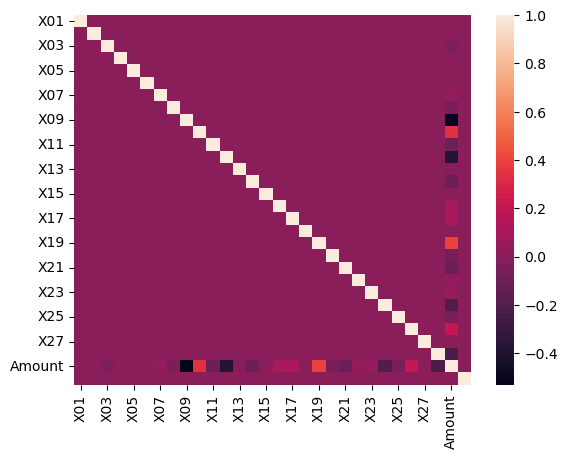

In [5]:
sns.heatmap(data.corr())
plt.show()

In [6]:
print(data.corr())

                         X01           X02           X03           X04  \
X01             1.000000e+00  3.510783e-08 -6.961353e-09 -5.201789e-09   
X02             3.510783e-08  1.000000e+00  2.692539e-09 -4.748080e-09   
X03            -6.961353e-09  2.692539e-09  1.000000e+00  2.474275e-08   
X04            -5.201789e-09 -4.748080e-09  2.474275e-08  1.000000e+00   
X05            -2.540238e-08  3.983898e-08 -1.199544e-08 -2.292273e-08   
X06            -5.716581e-09  4.110540e-08 -1.316175e-08 -4.027843e-08   
X07            -3.928462e-08 -4.082393e-08 -5.894457e-08 -1.853785e-08   
X08            -2.028889e-08  4.007208e-08 -2.021444e-08  2.273120e-08   
X09             4.277181e-08  1.312996e-08 -4.340287e-09  3.207382e-08   
X10             2.069657e-08 -2.096664e-08  3.350471e-08 -3.946882e-08   
X11            -3.550455e-08  7.718754e-09  9.930752e-09 -5.045341e-09   
X12            -4.594146e-08  1.098084e-08  8.759240e-09 -2.061103e-09   
X13            -4.201856e-08 -1.130329

In [8]:
df_pca = data.drop(['Amount','Transaction_ID'],axis = 1)
df_pca

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28
0,0.288031,0.533099,-0.750054,-0.622710,0.355750,-0.066000,0.290031,0.252320,0.967904,-0.043124,...,0.636818,-0.226253,0.065213,-0.019050,0.039540,1.577486,-0.761577,-0.701221,1.501575,-0.450915
1,-0.490082,0.713361,-1.576719,-0.603743,-1.064526,-0.210060,1.117863,-0.646029,0.326218,0.300454,...,2.203071,0.898595,-0.335998,-0.134917,0.213190,-0.225310,1.796268,-0.765555,0.542492,-1.424360
2,0.337351,-0.828948,-0.843122,-1.369146,0.452701,-0.491439,0.277849,-0.041046,0.709560,0.041543,...,1.202652,0.310072,-0.389947,-0.059352,0.534841,0.614328,0.171136,-0.411693,0.183883,-0.465929
3,-2.066729,0.114450,-0.756314,0.615028,-0.206941,1.116745,0.131014,-0.838473,-0.694850,-0.436614,...,-0.246610,-0.630127,-0.022732,-0.065497,0.199421,0.000145,0.327291,-0.589111,-0.574982,1.249703
4,0.470390,0.662612,0.261084,0.305759,-0.314468,0.143505,-0.584696,0.273699,0.095393,-0.168639,...,0.068264,-0.818843,0.354065,-0.067891,0.158497,-1.608643,-0.321899,-0.669961,1.253848,2.019645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.188069,0.000866,0.462066,-0.261152,0.575270,0.199415,0.178386,0.070972,-0.019557,-0.199037,...,0.204190,-0.632905,0.341340,-0.064071,-1.021917,-1.054815,-0.295774,-1.117063,-0.602785,2.055117
284803,-1.457867,0.044336,0.303596,-0.240991,0.025716,-0.065406,-0.125746,-1.105472,-1.068707,-0.525039,...,-0.806892,0.592594,0.044639,0.040773,1.700193,-0.511817,-0.067523,-0.711937,-1.234320,1.982674
284804,0.815654,0.453436,-0.085707,0.991589,-0.061046,0.142082,0.099296,-0.296249,2.442039,-0.060805,...,-0.490052,-1.004119,0.292336,0.052261,-0.035590,-2.258476,-0.177398,-1.048932,-1.367234,-1.944734
284805,0.087063,0.243026,0.859579,-0.010583,-1.322841,0.332658,0.067256,-0.206524,-0.463291,-0.137508,...,-0.869297,0.133557,0.051104,0.017088,-0.062124,1.287554,0.073211,0.377536,1.151844,1.013139


In [9]:
sc = StandardScaler()
df_pca_scaled = sc.fit_transform(df_pca)
df_pca_scaled

array([[  0.32870791,   0.88021529,  -0.68271736, ...,  -0.52633586,
          1.47110675,  -0.23021235],
       [ -0.55929436,   1.17785202,  -1.43516771, ...,  -0.57462527,
          0.53148465,  -0.72719952],
       [  0.38499312,  -1.36870134,  -0.76743042, ...,  -0.30901656,
          0.18015203,  -0.23787762],
       ...,
       [  0.93084457,   0.74868221,  -0.07801289, ...,  -0.7873276 ,
         -1.33949195,  -0.99287375],
       [  0.09935858,   0.40126731,   0.78240956, ...,   0.28337817,
          1.12847194,   0.5172528 ],
       [  1.41368407,  -0.30325151,   2.75027391, ...,   0.41639765,
          2.20979496, -10.97461128]])

In [10]:
df_PCA = pd.DataFrame(columns= df_pca.columns,index=df_pca.index,data= df_pca_scaled)
df_PCA

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28
0,0.328708,0.880215,-0.682717,-0.733174,0.357440,-0.136865,0.302558,0.309960,0.586145,-0.055937,...,0.514771,-0.311772,0.104431,-0.047196,0.047174,1.040385,-1.460982,-0.526336,1.471107,-0.230212
1,-0.559294,1.177852,-1.435168,-0.710841,-1.069582,-0.435605,1.166148,-0.793609,0.197551,0.389733,...,1.780848,1.238246,-0.538063,-0.334258,0.254351,-0.148597,3.445898,-0.574625,0.531485,-0.727200
2,0.384993,-1.368701,-0.767430,-1.612020,0.454851,-1.019104,0.289851,-0.050422,0.429697,0.053887,...,0.972161,0.427273,-0.624456,-0.147046,0.638102,0.405162,0.328302,-0.309017,0.180152,-0.237878
3,-2.358603,0.188971,-0.688416,0.724128,-0.207924,2.315812,0.136674,-1.030015,-0.420788,-0.566352,...,-0.199347,-0.868302,-0.036403,-0.162269,0.237923,0.000096,0.627864,-0.442187,-0.563315,0.638029
4,0.536821,1.094058,0.237645,0.359998,-0.315962,0.297589,-0.609952,0.336223,0.057768,-0.218750,...,0.055181,-1.128349,0.566994,-0.168201,0.189098,-1.060933,-0.617521,-0.502872,1.228407,1.031119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.214629,0.001430,0.420584,-0.307478,0.578003,0.413529,0.186091,0.087185,-0.011844,-0.258180,...,0.165056,-0.872130,0.546616,-0.158735,-1.219217,-0.695673,-0.567402,-0.838466,-0.590554,1.049229
284803,-1.663755,0.073205,0.276341,-0.283741,0.025838,-0.135634,-0.131177,-1.358008,-0.647189,-0.681052,...,-0.652249,0.816583,0.071484,0.101014,2.028447,-0.337554,-0.129534,-0.534379,-1.209275,1.012244
284804,0.930845,0.748682,-0.078013,1.167488,-0.061336,0.294639,0.103585,-0.363924,1.478854,-0.078872,...,-0.396132,-1.383656,0.468142,0.129477,-0.042461,-1.489512,-0.340315,-0.787328,-1.339492,-0.992874
284805,0.099359,0.401267,0.782410,-0.012460,-1.329125,0.689837,0.070161,-0.253703,-0.280560,-0.178368,...,-0.702694,0.184039,0.081837,0.042336,-0.074118,0.849169,0.140445,0.283378,1.128472,0.517253


# IsolationForest

In [81]:
X = data.drop('Transaction_ID',axis =1)
X

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X21,X22,X23,X24,X25,X26,X27,X28,Amount,anomaly_score
0,0.288031,0.533099,-0.750054,-0.622710,0.355750,-0.066000,0.290031,0.252320,0.967904,-0.043124,...,0.065213,-0.019050,0.039540,1.577486,-0.761577,-0.701221,1.501575,-0.450915,2.70,4.071309
1,-0.490082,0.713361,-1.576719,-0.603743,-1.064526,-0.210060,1.117863,-0.646029,0.326218,0.300454,...,-0.335998,-0.134917,0.213190,-0.225310,1.796268,-0.765555,0.542492,-1.424360,173.49,1.132376
2,0.337351,-0.828948,-0.843122,-1.369146,0.452701,-0.491439,0.277849,-0.041046,0.709560,0.041543,...,-0.389947,-0.059352,0.534841,0.614328,0.171136,-0.411693,0.183883,-0.465929,0.91,1.017139
3,-2.066729,0.114450,-0.756314,0.615028,-0.206941,1.116745,0.131014,-0.838473,-0.694850,-0.436614,...,-0.022732,-0.065497,0.199421,0.000145,0.327291,-0.589111,-0.574982,1.249703,65.00,1.033063
4,0.470390,0.662612,0.261084,0.305759,-0.314468,0.143505,-0.584696,0.273699,0.095393,-0.168639,...,0.354065,-0.067891,0.158497,-1.608643,-0.321899,-0.669961,1.253848,2.019645,1.31,0.998237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.188069,0.000866,0.462066,-0.261152,0.575270,0.199415,0.178386,0.070972,-0.019557,-0.199037,...,0.341340,-0.064071,-1.021917,-1.054815,-0.295774,-1.117063,-0.602785,2.055117,1.13,0.989978
284803,-1.457867,0.044336,0.303596,-0.240991,0.025716,-0.065406,-0.125746,-1.105472,-1.068707,-0.525039,...,0.044639,0.040773,1.700193,-0.511817,-0.067523,-0.711937,-1.234320,1.982674,73.00,1.055864
284804,0.815654,0.453436,-0.085707,0.991589,-0.061046,0.142082,0.099296,-0.296249,2.442039,-0.060805,...,0.292336,0.052261,-0.035590,-2.258476,-0.177398,-1.048932,-1.367234,-1.944734,14.00,1.053723
284805,0.087063,0.243026,0.859579,-0.010583,-1.322841,0.332658,0.067256,-0.206524,-0.463291,-0.137508,...,0.051104,0.017088,-0.062124,1.287554,0.073211,0.377536,1.151844,1.013139,42.72,1.014666


In [82]:
pipeline = Pipeline([
    ('sc',StandardScaler()),
    ('pca',PCA()),
    ('iso_forest',IsolationForest(contamination= 0.003,random_state=42))
])

In [83]:
param_grid = {
    'pca__n_components': [0.95, 0.99],  # Keep 95% or 99% variance
    'iso_forest__n_estimators': [50, 100, 200],
    'iso_forest__max_samples': ['auto', 256, 512],  # Subsampling size
    'iso_forest__bootstrap': [True, False]
}

In [84]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',  # For outlier detection
    cv=3,               # 3-fold cross-validation
    n_jobs=-1,          # Use all CPU cores
    verbose=1
)

In [85]:
grid_search.fit(X)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


C:\Anaconda3-2024.06\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('sc', StandardScaler()), ('pca', PCA()),
                                       ('iso_forest',
                                        IsolationForest(contamination=0.003,
                                                        random_state=42))]),
             n_jobs=-1,
             param_grid={'iso_forest__bootstrap': [True, False],
                         'iso_forest__max_samples': ['auto', 256, 512],
                         'iso_forest__n_estimators': [50, 100, 200],
                         'pca__n_components': [0.95, 0.99]},
             scoring='roc_auc', verbose=1)

In [86]:
print('Best Parameters are: ',grid_search.best_params_)

Best Parameters are:  {'iso_forest__bootstrap': True, 'iso_forest__max_samples': 'auto', 'iso_forest__n_estimators': 50, 'pca__n_components': 0.95}


In [87]:
best_model = grid_search.best_estimator_

In [88]:
data['Anomaly_Score'] = best_model.decision_function(X) 


In [89]:
data

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X23,X24,X25,X26,X27,X28,Amount,Transaction_ID,anomaly_score,Anomaly_Score
0,0.288031,0.533099,-0.750054,-0.622710,0.355750,-0.066000,0.290031,0.252320,0.967904,-0.043124,...,0.039540,1.577486,-0.761577,-0.701221,1.501575,-0.450915,2.70,9991622972803468315,4.071309,0.324507
1,-0.490082,0.713361,-1.576719,-0.603743,-1.064526,-0.210060,1.117863,-0.646029,0.326218,0.300454,...,0.213190,-0.225310,1.796268,-0.765555,0.542492,-1.424360,173.49,11084406015651466253,1.132376,0.250219
2,0.337351,-0.828948,-0.843122,-1.369146,0.452701,-0.491439,0.277849,-0.041046,0.709560,0.041543,...,0.534841,0.614328,0.171136,-0.411693,0.183883,-0.465929,0.91,10197587932662340273,1.017139,0.304339
3,-2.066729,0.114450,-0.756314,0.615028,-0.206941,1.116745,0.131014,-0.838473,-0.694850,-0.436614,...,0.199421,0.000145,0.327291,-0.589111,-0.574982,1.249703,65.00,13576113269769860024,1.033063,0.287194
4,0.470390,0.662612,0.261084,0.305759,-0.314468,0.143505,-0.584696,0.273699,0.095393,-0.168639,...,0.158497,-1.608643,-0.321899,-0.669961,1.253848,2.019645,1.31,7097340918492760609,0.998237,0.324645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.188069,0.000866,0.462066,-0.261152,0.575270,0.199415,0.178386,0.070972,-0.019557,-0.199037,...,-1.021917,-1.054815,-0.295774,-1.117063,-0.602785,2.055117,1.13,11729897455233410244,0.989978,0.335717
284803,-1.457867,0.044336,0.303596,-0.240991,0.025716,-0.065406,-0.125746,-1.105472,-1.068707,-0.525039,...,1.700193,-0.511817,-0.067523,-0.711937,-1.234320,1.982674,73.00,17893056505877857918,1.055864,0.306750
284804,0.815654,0.453436,-0.085707,0.991589,-0.061046,0.142082,0.099296,-0.296249,2.442039,-0.060805,...,-0.035590,-2.258476,-0.177398,-1.048932,-1.367234,-1.944734,14.00,5549215154615627988,1.053723,0.292004
284805,0.087063,0.243026,0.859579,-0.010583,-1.322841,0.332658,0.067256,-0.206524,-0.463291,-0.137508,...,-0.062124,1.287554,0.073211,0.377536,1.151844,1.013139,42.72,18353789654090332728,1.014666,0.331152


In [90]:
data['is_fraud_pred'] = best_model.predict(X)
data

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X24,X25,X26,X27,X28,Amount,Transaction_ID,anomaly_score,Anomaly_Score,is_fraud_pred
0,0.288031,0.533099,-0.750054,-0.622710,0.355750,-0.066000,0.290031,0.252320,0.967904,-0.043124,...,1.577486,-0.761577,-0.701221,1.501575,-0.450915,2.70,9991622972803468315,4.071309,0.324507,1
1,-0.490082,0.713361,-1.576719,-0.603743,-1.064526,-0.210060,1.117863,-0.646029,0.326218,0.300454,...,-0.225310,1.796268,-0.765555,0.542492,-1.424360,173.49,11084406015651466253,1.132376,0.250219,1
2,0.337351,-0.828948,-0.843122,-1.369146,0.452701,-0.491439,0.277849,-0.041046,0.709560,0.041543,...,0.614328,0.171136,-0.411693,0.183883,-0.465929,0.91,10197587932662340273,1.017139,0.304339,1
3,-2.066729,0.114450,-0.756314,0.615028,-0.206941,1.116745,0.131014,-0.838473,-0.694850,-0.436614,...,0.000145,0.327291,-0.589111,-0.574982,1.249703,65.00,13576113269769860024,1.033063,0.287194,1
4,0.470390,0.662612,0.261084,0.305759,-0.314468,0.143505,-0.584696,0.273699,0.095393,-0.168639,...,-1.608643,-0.321899,-0.669961,1.253848,2.019645,1.31,7097340918492760609,0.998237,0.324645,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.188069,0.000866,0.462066,-0.261152,0.575270,0.199415,0.178386,0.070972,-0.019557,-0.199037,...,-1.054815,-0.295774,-1.117063,-0.602785,2.055117,1.13,11729897455233410244,0.989978,0.335717,1
284803,-1.457867,0.044336,0.303596,-0.240991,0.025716,-0.065406,-0.125746,-1.105472,-1.068707,-0.525039,...,-0.511817,-0.067523,-0.711937,-1.234320,1.982674,73.00,17893056505877857918,1.055864,0.306750,1
284804,0.815654,0.453436,-0.085707,0.991589,-0.061046,0.142082,0.099296,-0.296249,2.442039,-0.060805,...,-2.258476,-0.177398,-1.048932,-1.367234,-1.944734,14.00,5549215154615627988,1.053723,0.292004,1
284805,0.087063,0.243026,0.859579,-0.010583,-1.322841,0.332658,0.067256,-0.206524,-0.463291,-0.137508,...,1.287554,0.073211,0.377536,1.151844,1.013139,42.72,18353789654090332728,1.014666,0.331152,1


In [95]:
top_100_frauds = data[data['is_fraud_pred'] == -1].nsmallest(100, 'Anomaly_Score')

In [99]:
top_100 = top_100_frauds.iloc[:,[28,29,31]].sort_values(by='Anomaly_Score',ascending = True)

In [100]:
top_100

,Amount,Transaction_ID,Anomaly_Score
125594,1593.38,15614498428204994409,-0.088609
58211,519.78,3319098694104553408,-0.088475
240278,200.00,9559447120572459095,-0.088475
41236,4543.66,2037581199645320223,-0.087119
190097,4861.65,17501639183481353783,-0.086074
...,...,...,...
189705,1.99,14108845963418183805,-0.054076
251678,1.99,7788010093526493081,-0.054076
282704,2000.00,7575530676634340329,-0.053871
52820,12910.95,11667323465015229506,-0.053834


In [101]:
HTML(top_100.to_html())

,Amount,Transaction_ID,Anomaly_Score
125594,1593.38,15614498428204994409,-0.088609
58211,519.78,3319098694104553408,-0.088475
240278,200.00,9559447120572459095,-0.088475
41236,4543.66,2037581199645320223,-0.087119
190097,4861.65,17501639183481353783,-0.086074
219797,1676.61,9297534395402375562,-0.085340
170934,500.00,12382800714479079128,-0.083698
209256,243.27,2590330456260053380,-0.081855
1890,1201.85,2138086120417120015,-0.081730
238704,305.27,1285605336319112113,-0.080582


# Local Outlier Factor (LOF)

- LOF is an anomaly detection algorithm that identifies outliers based on how isolated a data point is compared to its neighbors. Unlike Isolation Forest (which assumes anomalies are "few and different"), LOF is great for detecting local anomalies—points that seem normal globally but are weird in their immediate vicinity.



In [56]:
data = pd.read_csv('vlk_fraud 1.csv')
data

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X21,X22,X23,X24,X25,X26,X27,X28,Amount,Transaction_ID
0,0.288031,0.533099,-0.750054,-0.622710,0.355750,-0.066000,0.290031,0.252320,0.967904,-0.043124,...,0.065213,-0.019050,0.039540,1.577486,-0.761577,-0.701221,1.501575,-0.450915,2.70,9991622972803468315
1,-0.490082,0.713361,-1.576719,-0.603743,-1.064526,-0.210060,1.117863,-0.646029,0.326218,0.300454,...,-0.335998,-0.134917,0.213190,-0.225310,1.796268,-0.765555,0.542492,-1.424360,173.49,11084406015651466253
2,0.337351,-0.828948,-0.843122,-1.369146,0.452701,-0.491439,0.277849,-0.041046,0.709560,0.041543,...,-0.389947,-0.059352,0.534841,0.614328,0.171136,-0.411693,0.183883,-0.465929,0.91,10197587932662340273
3,-2.066729,0.114450,-0.756314,0.615028,-0.206941,1.116745,0.131014,-0.838473,-0.694850,-0.436614,...,-0.022732,-0.065497,0.199421,0.000145,0.327291,-0.589111,-0.574982,1.249703,65.00,13576113269769860024
4,0.470390,0.662612,0.261084,0.305759,-0.314468,0.143505,-0.584696,0.273699,0.095393,-0.168639,...,0.354065,-0.067891,0.158497,-1.608643,-0.321899,-0.669961,1.253848,2.019645,1.31,7097340918492760609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.188069,0.000866,0.462066,-0.261152,0.575270,0.199415,0.178386,0.070972,-0.019557,-0.199037,...,0.341340,-0.064071,-1.021917,-1.054815,-0.295774,-1.117063,-0.602785,2.055117,1.13,11729897455233410244
284803,-1.457867,0.044336,0.303596,-0.240991,0.025716,-0.065406,-0.125746,-1.105472,-1.068707,-0.525039,...,0.044639,0.040773,1.700193,-0.511817,-0.067523,-0.711937,-1.234320,1.982674,73.00,17893056505877857918
284804,0.815654,0.453436,-0.085707,0.991589,-0.061046,0.142082,0.099296,-0.296249,2.442039,-0.060805,...,0.292336,0.052261,-0.035590,-2.258476,-0.177398,-1.048932,-1.367234,-1.944734,14.00,5549215154615627988
284805,0.087063,0.243026,0.859579,-0.010583,-1.322841,0.332658,0.067256,-0.206524,-0.463291,-0.137508,...,0.051104,0.017088,-0.062124,1.287554,0.073211,0.377536,1.151844,1.013139,42.72,18353789654090332728


In [59]:
X = data.drop('Transaction_ID',axis =1)


In [64]:
pipeline = Pipeline([
    ('sc',StandardScaler()),
    ('variance_threshold',VarianceThreshold(threshold=0.1)),
    ('lof',LocalOutlierFactor(novelty=True, contamination= 'auto')) # Auto estimate outlier detection
])

In [65]:
param_grid = {
    'variance_threshold__threshold': [0.01, 0.1, 0.5],  # Test different variance cutoffs
    'lof__n_neighbors': [20, 50, 100],  # Smaller k = more local sensitivity
    'lof__metric': ['euclidean', 'manhattan']  # Distance metric
}

In [66]:
# GridSearch with 3-fold CV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # For unsupervised scoring
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [67]:
grid_search.fit(X)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


C:\Anaconda3-2024.06\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('variance_threshold',
                                        VarianceThreshold(threshold=0.1)),
                                       ('lof',
                                        LocalOutlierFactor(novelty=True))]),
             n_jobs=-1,
             param_grid={'lof__metric': ['euclidean', 'manhattan'],
                         'lof__n_neighbors': [20, 50, 100],
                         'variance_threshold__threshold': [0.01, 0.1, 0.5]},
             scoring='neg_mean_squared_error', verbose=1)

In [68]:
best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'lof__metric': 'euclidean', 'lof__n_neighbors': 20, 'variance_threshold__threshold': 0.01}


In [69]:
X_scores = -best_model.named_steps['lof'].negative_outlier_factor_  # Higher = more anomalous
data['anomaly_score'] = X_scores
data

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X22,X23,X24,X25,X26,X27,X28,Amount,Transaction_ID,anomaly_score
0,0.288031,0.533099,-0.750054,-0.622710,0.355750,-0.066000,0.290031,0.252320,0.967904,-0.043124,...,-0.019050,0.039540,1.577486,-0.761577,-0.701221,1.501575,-0.450915,2.70,9991622972803468315,4.071309
1,-0.490082,0.713361,-1.576719,-0.603743,-1.064526,-0.210060,1.117863,-0.646029,0.326218,0.300454,...,-0.134917,0.213190,-0.225310,1.796268,-0.765555,0.542492,-1.424360,173.49,11084406015651466253,1.132376
2,0.337351,-0.828948,-0.843122,-1.369146,0.452701,-0.491439,0.277849,-0.041046,0.709560,0.041543,...,-0.059352,0.534841,0.614328,0.171136,-0.411693,0.183883,-0.465929,0.91,10197587932662340273,1.017139
3,-2.066729,0.114450,-0.756314,0.615028,-0.206941,1.116745,0.131014,-0.838473,-0.694850,-0.436614,...,-0.065497,0.199421,0.000145,0.327291,-0.589111,-0.574982,1.249703,65.00,13576113269769860024,1.033063
4,0.470390,0.662612,0.261084,0.305759,-0.314468,0.143505,-0.584696,0.273699,0.095393,-0.168639,...,-0.067891,0.158497,-1.608643,-0.321899,-0.669961,1.253848,2.019645,1.31,7097340918492760609,0.998237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.188069,0.000866,0.462066,-0.261152,0.575270,0.199415,0.178386,0.070972,-0.019557,-0.199037,...,-0.064071,-1.021917,-1.054815,-0.295774,-1.117063,-0.602785,2.055117,1.13,11729897455233410244,0.989978
284803,-1.457867,0.044336,0.303596,-0.240991,0.025716,-0.065406,-0.125746,-1.105472,-1.068707,-0.525039,...,0.040773,1.700193,-0.511817,-0.067523,-0.711937,-1.234320,1.982674,73.00,17893056505877857918,1.055864
284804,0.815654,0.453436,-0.085707,0.991589,-0.061046,0.142082,0.099296,-0.296249,2.442039,-0.060805,...,0.052261,-0.035590,-2.258476,-0.177398,-1.048932,-1.367234,-1.944734,14.00,5549215154615627988,1.053723
284805,0.087063,0.243026,0.859579,-0.010583,-1.322841,0.332658,0.067256,-0.206524,-0.463291,-0.137508,...,0.017088,-0.062124,1.287554,0.073211,0.377536,1.151844,1.013139,42.72,18353789654090332728,1.014666


In [75]:
top_100_frauds_LOF = data.nsmallest(100, 'anomaly_score')
top_100_frauds_LOF

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X22,X23,X24,X25,X26,X27,X28,Amount,Transaction_ID,anomaly_score
159765,-0.046049,-0.119901,0.604153,-0.321949,-0.256479,0.206326,0.335270,0.204358,-0.076266,-0.243666,...,-0.073033,-0.779210,-1.132598,-0.290075,-1.138129,-0.932127,2.074207,0.90,1552443564812668934,0.854981
40590,-0.046051,-0.119896,0.604170,-0.321934,-0.256503,0.206337,0.335276,0.204333,-0.076397,-0.243558,...,-0.073036,-0.779209,-1.132663,-0.290102,-1.138090,-0.932115,2.074115,0.95,3928095813888501526,0.855064
280338,-0.046036,-0.119903,0.604166,-0.321943,-0.256470,0.206332,0.335303,0.204326,-0.076582,-0.243445,...,-0.073050,-0.779170,-1.132712,-0.290118,-1.138094,-0.932129,2.074010,1.01,835640503954648882,0.855151
173972,-0.046064,-0.119902,0.604159,-0.321934,-0.256487,0.206336,0.335289,0.204321,-0.076576,-0.243435,...,-0.073049,-0.779184,-1.132726,-0.290113,-1.138085,-0.932118,2.074005,1.01,2159523624015480762,0.855153
44313,-0.045935,-0.119851,0.604066,-0.321914,-0.256317,0.206242,0.335477,0.204074,-0.079143,-0.241820,...,-0.073171,-0.779037,-1.133604,-0.290406,-1.137802,-0.932112,2.072441,1.80,4751783918427007765,0.856355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197177,0.506033,0.641921,0.375771,0.349076,-1.072213,0.145972,-0.433721,0.278628,0.038291,-0.215779,...,-0.072967,0.251656,-1.625197,-0.347787,-0.687762,1.124606,2.017749,1.99,15886537018361845240,0.912034
150349,0.506038,0.641901,0.375745,0.349073,-1.072217,0.145977,-0.433741,0.278594,0.038292,-0.215802,...,-0.072974,0.251636,-1.625166,-0.347791,-0.687757,1.124645,2.017751,2.00,8068344255520902616,0.912040
62106,0.506036,0.641897,0.375745,0.349076,-1.072210,0.145961,-0.433714,0.278614,0.038283,-0.215801,...,-0.072974,0.251634,-1.625182,-0.347777,-0.687769,1.124618,2.017761,2.00,18129563728880731827,0.912040
256597,0.506142,0.641948,0.375676,0.349109,-1.072096,0.145887,-0.433548,0.278381,0.036063,-0.214372,...,-0.073122,0.251785,-1.625976,-0.348050,-0.687510,1.124618,2.016391,2.69,743476480295451631,0.913341


In [102]:
top_100_frauds_LOF=top_100_frauds_LOF.iloc[:,[28,29,30]].sort_values(by='anomaly_score',ascending = True)

IndexError: positional indexers are out-of-bounds

In [78]:
HTML(top_100_frauds_LOF.to_html())

,Amount,Transaction_ID,anomaly_score
284188,4.51,3211910768721520751,0.913691
256597,2.69,743476480295451631,0.913341
62106,2.00,18129563728880731827,0.912040
150349,2.00,8068344255520902616,0.912040
197177,1.99,15886537018361845240,0.912034
149841,1.99,619680228044140412,0.912025
156752,1.99,13865191541525832218,0.911958
224786,0.90,2348314787216866966,0.911804
87830,1.80,38871899837350268,0.911804
88300,1.01,12455017823233884271,0.910831
